## Nama: Faiz Iqbal I'tishom
## NIM: 164231059
## Kelas: SD-A1
## Tugas Klasifikasi I

### Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

### Subset Data

In [22]:
df_train = pd.read_csv('C:/Uner/Semester 4/Data Mining I/Week 6/Data_Latih.csv')
df_test = pd.read_csv('C:/Uner/Semester 4/Data Mining I/Week 6/Data_Uji.csv')

In [23]:
df_train.head()

,R,G,B,Rasa
0,137,112,73,Manis
1,125,103,65,Manis
2,135,80,28,Manis
3,153,110,24,Manis
4,123,96,23,Manis


In [24]:
df_test.head()

,R,G,B,Rasa
0,117,105,81,Manis
1,125,115,15,Manis
2,131,74,31,Manis
3,116,110,63,Manis
4,131,107,40,Manis


### Labeling

In [25]:
label_encoders = {}
for column in df_train.columns:
    le = LabelEncoder()
    df_train[column] = le.fit_transform(df_train[column])

    unseen_labels = set(df_test[column]) - set(le.classes_)

    if unseen_labels:
        print(f"Peringatan: Kolom '{column}' mengandung nilai yang tidak dikenali: {unseen_labels}")
        le.classes_ = np.append(le.classes_, list(unseen_labels))
    
    df_test[column] = le.transform(df_test[column])
    label_encoders[column] = le


Peringatan: Kolom 'R' mengandung nilai yang tidak dikenali: {65, 131, 68, 105, 142, 117, 86, 118, 90, 27, 124}
Peringatan: Kolom 'G' mengandung nilai yang tidak dikenali: {135, 43, 145, 117, 119, 122, 93, 126}
Peringatan: Kolom 'B' mengandung nilai yang tidak dikenali: {3, 48, 17, 81, 60, 63}


### Splitting Data

In [26]:
X_train = df_train.drop(columns=['Rasa']) 
y_train = df_train['Rasa']
X_test = df_test.drop(columns=['Rasa'])
y_test = df_test['Rasa']

### Build Model

In [27]:

clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Evaluate Model

In [28]:
# Evaluate model
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.73
Precision: 0.75
Recall: 0.73
F1 Score: 0.73

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.82      0.72        11
           1       0.86      0.60      0.71        10
           2       0.78      0.78      0.78         9

    accuracy                           0.73        30
   macro avg       0.76      0.73      0.73        30
weighted avg       0.75      0.73      0.73        30



### Display tree structure

In [29]:
tree_rules = export_text(clf, feature_names=list(X_train.columns))
print(tree_rules)



|--- R <= 31.50
|   |--- G <= 30.50
|   |   |--- R <= 24.50
|   |   |   |--- B <= 25.00
|   |   |   |   |--- G <= 20.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- G >  20.50
|   |   |   |   |   |--- R <= 10.50
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- R >  10.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- B >  25.00
|   |   |   |   |--- B <= 36.50
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- B >  36.50
|   |   |   |   |   |--- class: 0
|   |   |--- R >  24.50
|   |   |   |--- G <= 18.50
|   |   |   |   |--- class: 1
|   |   |   |--- G >  18.50
|   |   |   |   |--- class: 0
|   |--- G >  30.50
|   |   |--- R <= 22.50
|   |   |   |--- R <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- R >  2.50
|   |   |   |   |--- class: 2
|   |   |--- R >  22.50
|   |   |   |--- G <= 38.50
|   |   |   |   |--- class: 0
|   |   |   |--- G >  38.50
|   |   |   |   |--- R <= 25.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- R >  25.00


### Plot decision tree

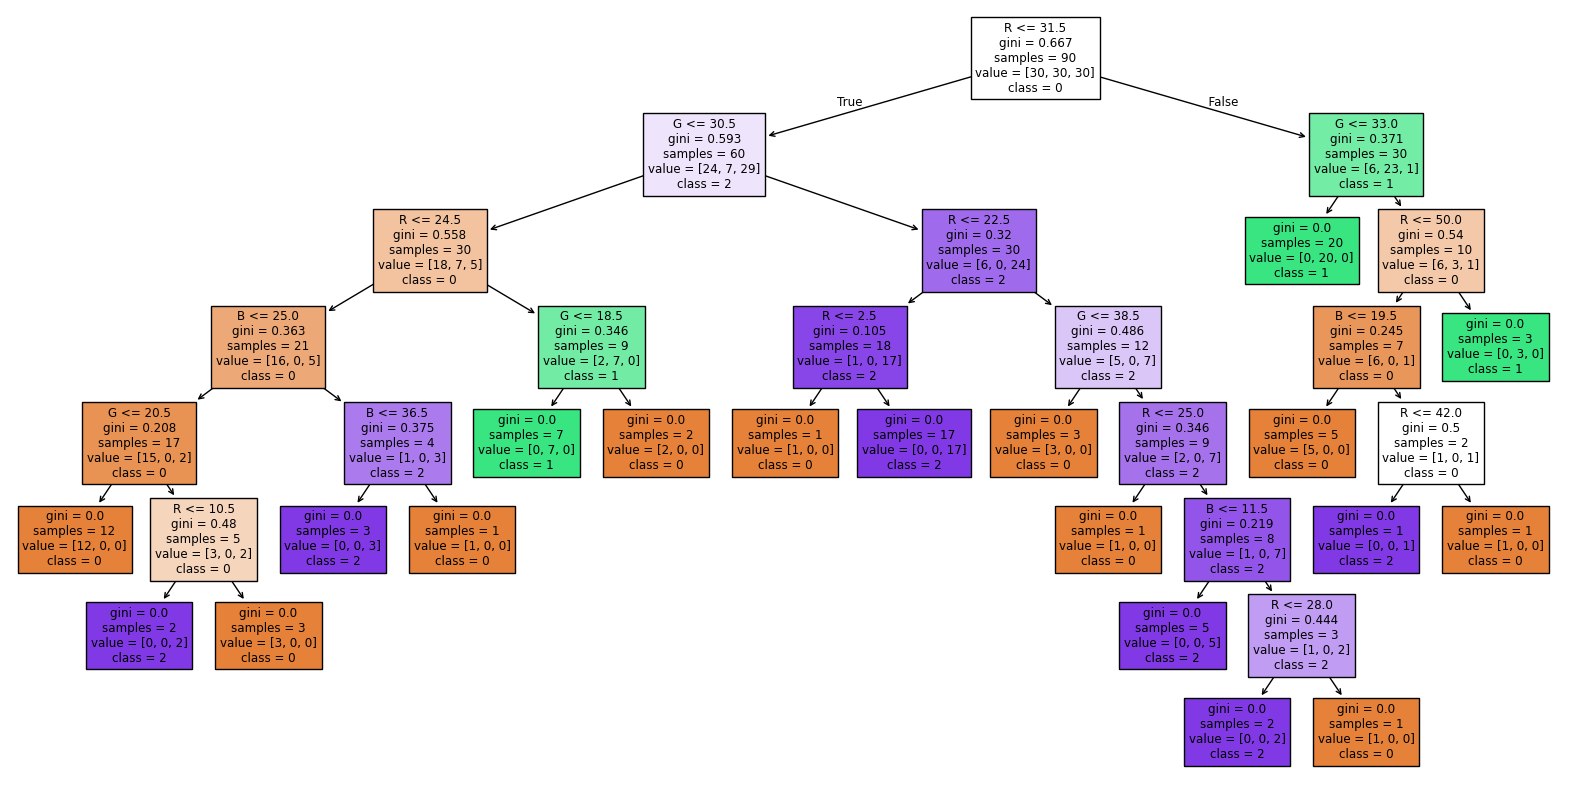

In [30]:
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X_train.columns, class_names=[str(i) for i in set(y_train)], filled=True)
plt.show()



### Confusion Matrix

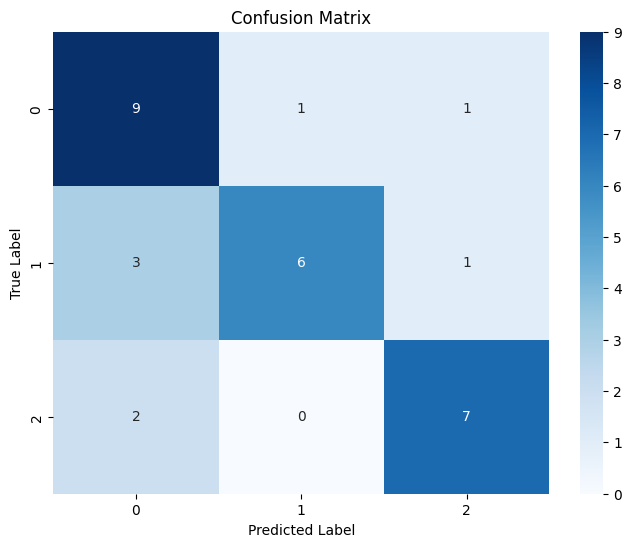

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()